# LSTM vs GRU — AAPL Stock Price Prediction - Torch

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Load & Preprocess Data

In [37]:
# Load data
data = pd.read_csv('top50_adjclose_2010_2025.csv')
apple_data = data[['Date', 'AAPL']].copy()
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
apple_data = apple_data.dropna().reset_index(drop=True)

apple_prices = apple_data['AAPL'].values.reshape(-1, 1)

def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 60
X_raw, y_raw = create_sequences(apple_prices, lookback)

train_size = int(0.7  * len(X_raw))
val_size   = int(0.15 * len(X_raw))

X_train_raw, y_train_raw = X_raw[:train_size],                    y_raw[:train_size]
X_val_raw,   y_val_raw   = X_raw[train_size:train_size+val_size], y_raw[train_size:train_size+val_size]
X_test_raw,  y_test_raw  = X_raw[train_size+val_size:],           y_raw[train_size+val_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
y_train = scaler.transform(y_train_raw)

X_val = scaler.transform(X_val_raw.reshape(-1, 1)).reshape(X_val_raw.shape)
y_val = scaler.transform(y_val_raw)

X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw)

## 2. Dataset & DataLoaders

In [38]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StockDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(StockDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

## 3. Model Definitions — LSTM & GRU

In [39]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)   # last timestep


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)   # last timestep


lstm_model = LSTMModel()
gru_model  = GRUModel()

print('LSTM parameters:', sum(p.numel() for p in lstm_model.parameters()))
print('GRU  parameters:', sum(p.numel() for p in gru_model.parameters()))

LSTM parameters: 50497
GRU  parameters: 37889


## 4. Shared Training Function

In [40]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, model_name='Model'):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.6)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{model_name}] Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    # Restore best weights
    model.load_state_dict(best_state)
    print(f'[{model_name}] Best val loss: {best_val_loss:.6f}\n')
    return train_losses, val_losses

## 5. Train LSTM

In [41]:
EPOCHS = 200

lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, model_name='LSTM'
)

[LSTM] Epoch   1/200 | Train Loss: 0.044088 | Val Loss: 0.018360
[LSTM] Epoch  10/200 | Train Loss: 0.001113 | Val Loss: 0.009068
[LSTM] Epoch  20/200 | Train Loss: 0.001027 | Val Loss: 0.014901
[LSTM] Epoch  30/200 | Train Loss: 0.000825 | Val Loss: 0.007500
[LSTM] Epoch  40/200 | Train Loss: 0.000765 | Val Loss: 0.014788
[LSTM] Epoch  50/200 | Train Loss: 0.000740 | Val Loss: 0.007331
[LSTM] Epoch  60/200 | Train Loss: 0.000647 | Val Loss: 0.008802
[LSTM] Epoch  70/200 | Train Loss: 0.000572 | Val Loss: 0.011768
[LSTM] Epoch  80/200 | Train Loss: 0.000512 | Val Loss: 0.007924
[LSTM] Epoch  90/200 | Train Loss: 0.000617 | Val Loss: 0.007417
[LSTM] Epoch 100/200 | Train Loss: 0.000511 | Val Loss: 0.005123
[LSTM] Epoch 110/200 | Train Loss: 0.000537 | Val Loss: 0.006642
[LSTM] Epoch 120/200 | Train Loss: 0.000527 | Val Loss: 0.007177
[LSTM] Epoch 130/200 | Train Loss: 0.000507 | Val Loss: 0.006677
[LSTM] Epoch 140/200 | Train Loss: 0.000522 | Val Loss: 0.007503
[LSTM] Epoch 150/200 | Tr

## 6. Train GRU

In [42]:
gru_train_losses, gru_val_losses = train_model(
    gru_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, model_name='GRU'
)

[GRU] Epoch   1/200 | Train Loss: 0.031366 | Val Loss: 0.001535
[GRU] Epoch  10/200 | Train Loss: 0.000947 | Val Loss: 0.007733
[GRU] Epoch  20/200 | Train Loss: 0.000887 | Val Loss: 0.004945
[GRU] Epoch  30/200 | Train Loss: 0.000797 | Val Loss: 0.002119
[GRU] Epoch  40/200 | Train Loss: 0.000701 | Val Loss: 0.001449
[GRU] Epoch  50/200 | Train Loss: 0.000619 | Val Loss: 0.002018
[GRU] Epoch  60/200 | Train Loss: 0.000581 | Val Loss: 0.002258
[GRU] Epoch  70/200 | Train Loss: 0.000629 | Val Loss: 0.002097
[GRU] Epoch  80/200 | Train Loss: 0.000609 | Val Loss: 0.002580
[GRU] Epoch  90/200 | Train Loss: 0.000599 | Val Loss: 0.002337
[GRU] Epoch 100/200 | Train Loss: 0.000553 | Val Loss: 0.002415
[GRU] Epoch 110/200 | Train Loss: 0.000502 | Val Loss: 0.002546
[GRU] Epoch 120/200 | Train Loss: 0.000537 | Val Loss: 0.002741
[GRU] Epoch 130/200 | Train Loss: 0.000566 | Val Loss: 0.002342
[GRU] Epoch 140/200 | Train Loss: 0.000550 | Val Loss: 0.002321
[GRU] Epoch 150/200 | Train Loss: 0.0005

## 7. Training Curves

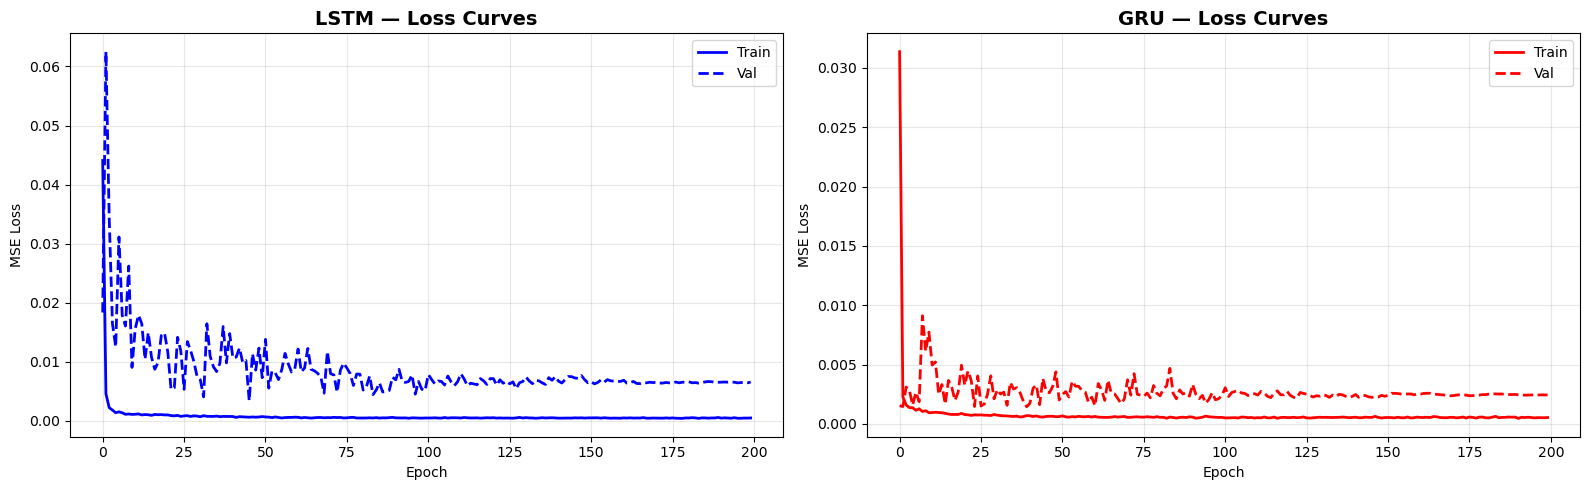

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, train_l, val_l, name, color in zip(
    axes,
    [lstm_train_losses, gru_train_losses],
    [lstm_val_losses,   gru_val_losses],
    ['LSTM', 'GRU'],
    ['blue', 'red']
):
    ax.plot(train_l, label='Train', color=color, linewidth=2)
    ax.plot(val_l,   label='Val',   color=color, linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Loss Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [44]:
def evaluate(model, loader):
    model.eval()
    preds_s, actuals_s = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            
            preds_s.append(model(X_batch).cpu().numpy())
            actuals_s.append(y_batch.numpy())
    preds_scaled   = np.concatenate(preds_s,   axis=0)
    actuals_scaled = np.concatenate(actuals_s, axis=0)
    preds   = scaler.inverse_transform(preds_scaled)
    actuals = scaler.inverse_transform(actuals_scaled)
    return preds, actuals

lstm_preds, actuals = evaluate(lstm_model, test_loader)
gru_preds,  _       = evaluate(gru_model,  test_loader)

# Test dates
test_start_idx = train_size + val_size + lookback
test_dates = apple_data['Date'].iloc[test_start_idx:test_start_idx + len(actuals)].values

def metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:6s} | MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MAPE: {mape:.2f}%')
    return mae, rmse, mape

print('Model  | MAE         | RMSE        | MAPE')
print('-' * 50)
lstm_metrics = metrics('LSTM', actuals, lstm_preds)
gru_metrics  = metrics('GRU',  actuals, gru_preds)

Model  | MAE         | RMSE        | MAPE
--------------------------------------------------
LSTM   | MAE: $33.96 | RMSE: $39.30 | MAPE: 15.00%
GRU    | MAE: $16.32 | RMSE: $19.78 | MAPE: 7.14%


## 9. Predicted vs Actual — LSTM & GRU Comparison

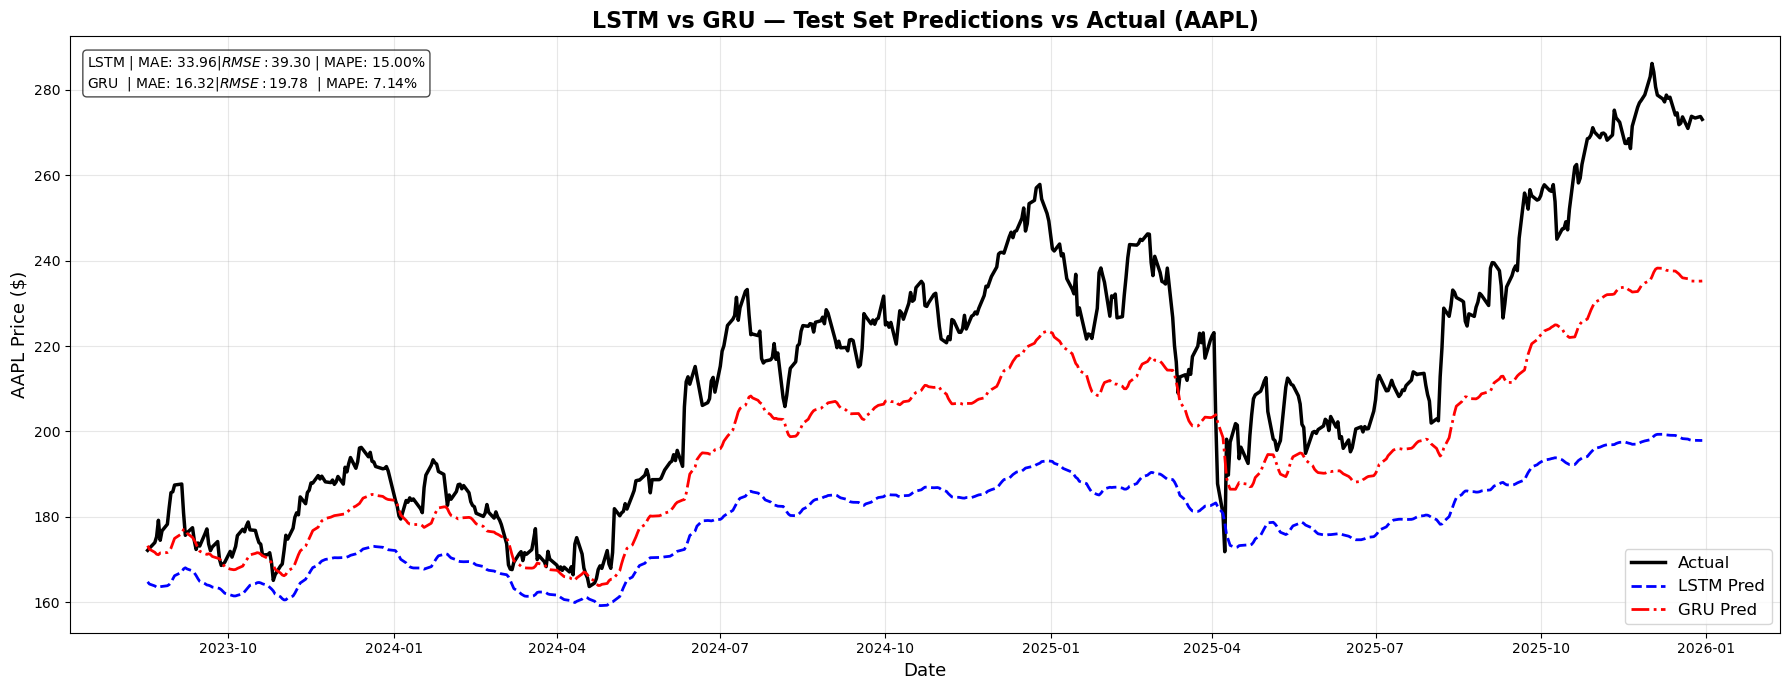

In [45]:
plt.figure(figsize=(18, 7))

plt.plot(test_dates, actuals,    label='Actual',    color='black',   linewidth=2.5)
plt.plot(test_dates, lstm_preds, label='LSTM Pred', color='blue', linewidth=2, linestyle='--')
plt.plot(test_dates, gru_preds,  label='GRU Pred',  color='red', linewidth=2, linestyle='-.')

plt.title('LSTM vs GRU — Test Set Predictions vs Actual (AAPL)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('AAPL Price ($)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Annotate metrics in the plot
textstr = (
    f"LSTM | MAE: ${lstm_metrics[0]:.2f} | RMSE: ${lstm_metrics[1]:.2f} | MAPE: {lstm_metrics[2]:.2f}%\n"
    f"GRU  | MAE: ${gru_metrics[0]:.2f}  | RMSE: ${gru_metrics[1]:.2f}  | MAPE: {gru_metrics[2]:.2f}%"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
plt.gca().text(
    0.01, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', bbox=props
)

plt.tight_layout()
plt.show()

## 10. Individual Subplots

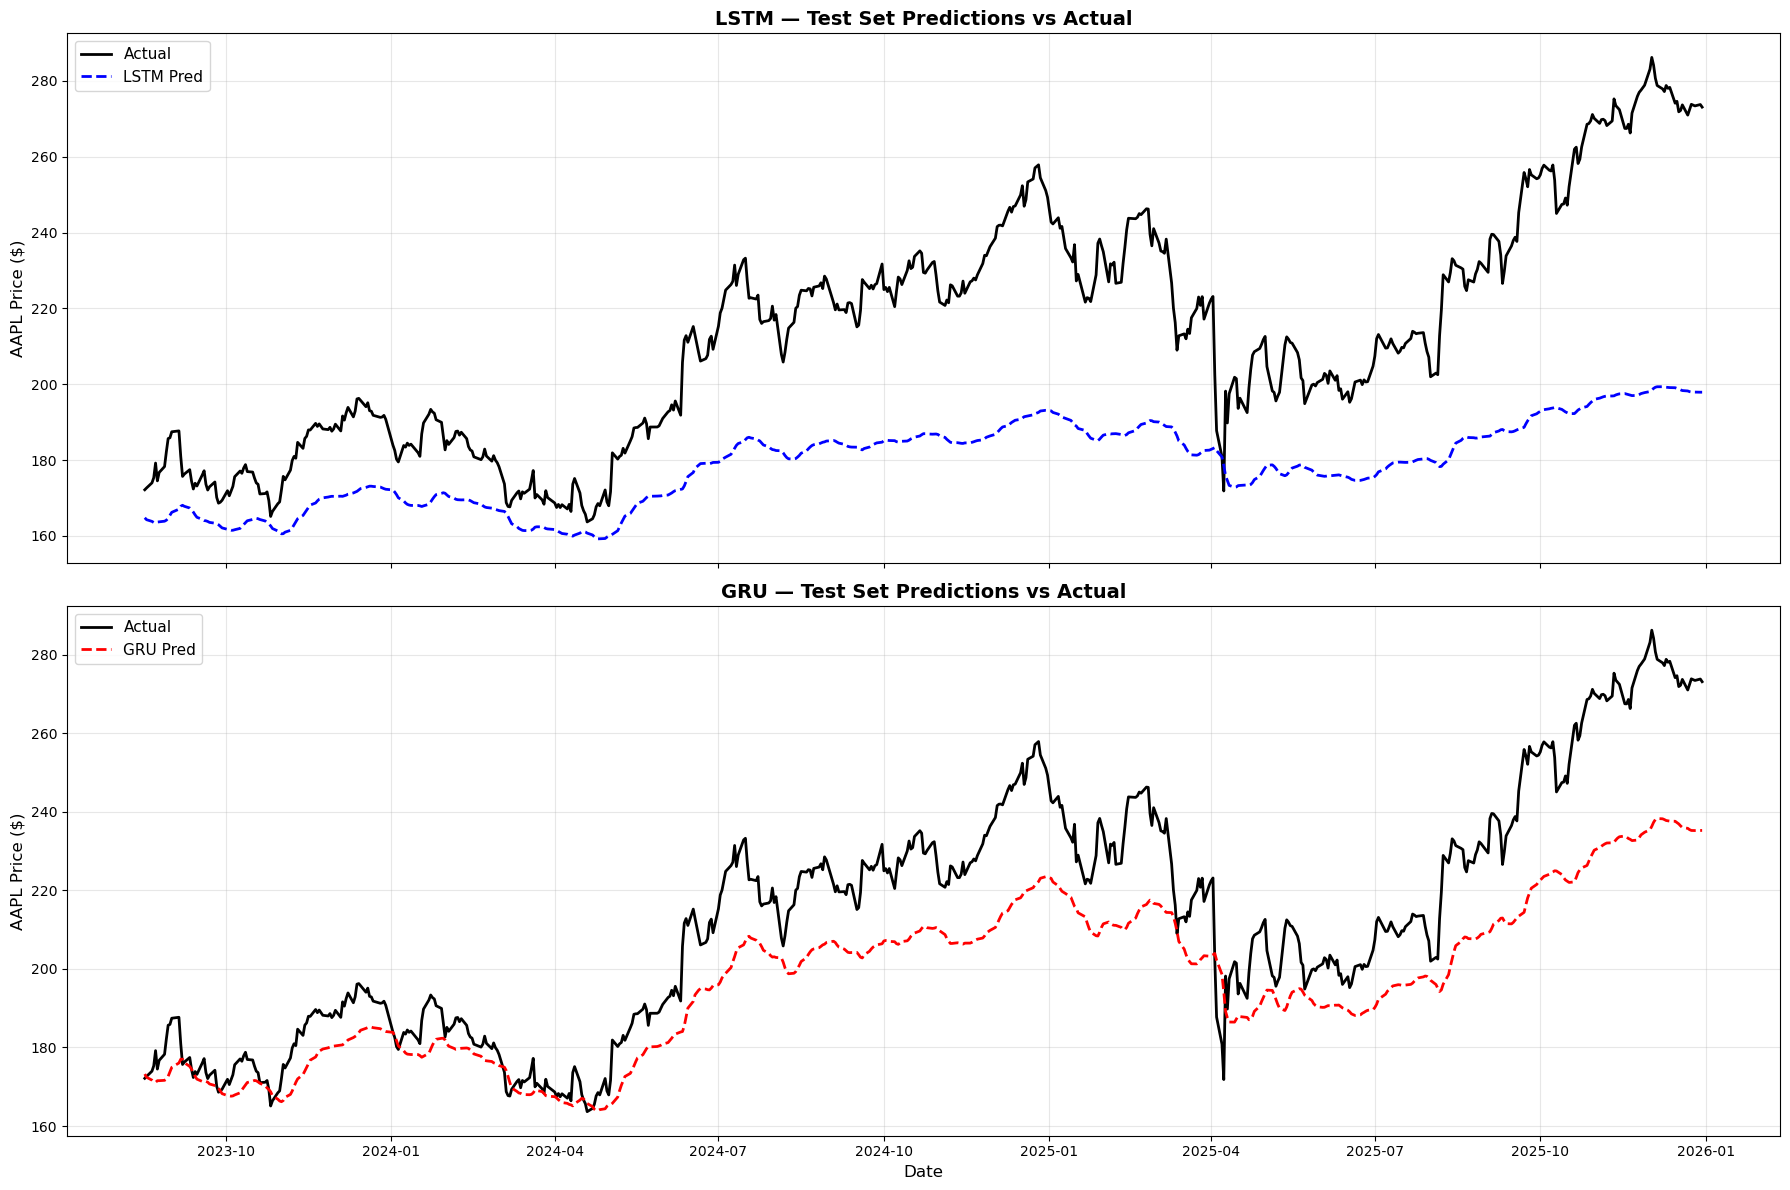

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

for ax, preds, name, color in zip(
    axes,
    [lstm_preds, gru_preds],
    ['LSTM', 'GRU'],
    ['blue', 'red']
):
    ax.plot(test_dates, actuals, label='Actual', color='black', linewidth=2)
    ax.plot(test_dates, preds, label=f'{name} Pred', color=color, linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Test Set Predictions vs Actual', fontsize=14, fontweight='bold')
    ax.set_ylabel('AAPL Price ($)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()